In [1]:
import ChessLens

from Dataset.DataSetLoaders import ChessDataset

import numpy as np
from matplotlib import pyplot as plt

from tqdm import tqdm

In [2]:
ds = ChessDataset.ChessDataset(
    root_dirs="/mnt/D/University/Thesis_Dataset/chessred2k",
    config={
        "img_size": (640,640)
    },
    force_build_pkl=True
)

'/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG001.jpg'

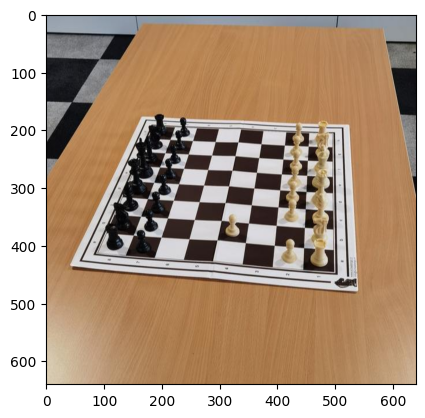

In [3]:
img, y = ds[1]

plt.imshow(img.permute(1,2,0));
y["image_path"]

'/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG001.jpg'

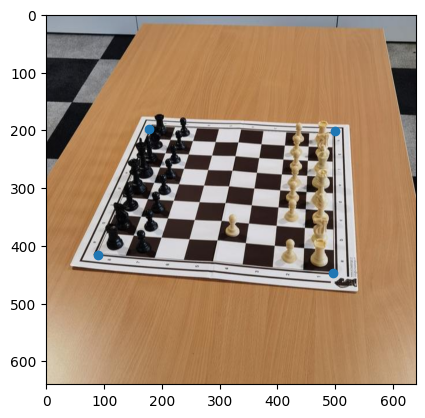

In [4]:
img = ChessLens.ChessLensImage(img)
img.detect_board()

plt.imshow(img.img.permute(1,2,0));
plt.scatter(img.board_detection[:,0], img.board_detection[:,1]);
img.board_detection.reshape(-1).to(int).tolist()

y["image_path"]

In [5]:
res = []

for i in tqdm(range(len(ds))):
    try:
        img, y = ds[i]

        img = ChessLens.ChessLensImage(img)
        img.detect_board()

        tmp = img.board_detection
        tmp[:,1] *= 480/640
        res.append(f"{y["image_path"]}:{",".join(map(lambda x: str(x), tmp.reshape(-1).to(int).tolist()))}")
    except:
        res.append(f"{y["image_path"]}:{",".join(["0"]*8)}")

        print(f"Image Failed at {y["image_path"]}")

res

 13%|█▎        | 263/2078 [01:34<12:21,  2.45it/s]

Image Failed at /mnt/D/University/Thesis_Dataset/chessred2k/images/19/G019_IMG039.jpg


100%|██████████| 2078/2078 [10:52<00:00,  3.18it/s]


['/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG000.jpg:96,167,373,97,546,238,222,360',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG001.jpg:177,148,500,150,497,334,89,312',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG002.jpg:81,195,373,131,566,267,224,381',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG003.jpg:254,103,530,162,401,344,86,255',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG004.jpg:233,92,567,165,432,393,54,272',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG005.jpg:122,94,458,86,547,257,80,270',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG006.jpg:147,135,463,129,529,376,146,384',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG007.jpg:75,177,288,83,537,150,344,309',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG008.jpg:49,187,346,118,581,249,240,379',
 '/mnt/D/University/Thesis_Dataset/chessred2k/images/0/G000_IMG009.j

In [6]:
with open("tmp.txt", "w") as f:
    f.write("\n".join(res))

# Testing

In [31]:
i = 50

93 /mnt/D/University/Thesis_Dataset/Phone_Angles_Dataset/game2/image_23.jpg
tensor([[191.0000,  93.3333],
        [469.0000, 104.0000],
        [603.0000, 508.0000],
        [105.0000, 494.6667]])


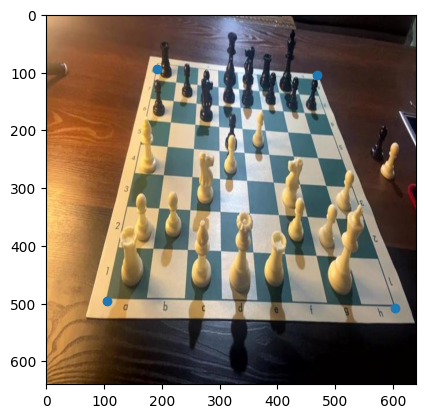

In [75]:
img, y = ds[i]

plt.imshow(img.permute(1,2,0));
plt.scatter(y["corners"][:,0], y["corners"][:,1]);

print(i, y["image_path"])
print(y["corners"])
i += 1